In [1]:
from itertools import product
from pathlib import Path

import jsonlines
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
from torchmetrics.classification import BinaryF1Score

from heisenberg_hamiltonians import HeisenbergJ1J2
from lattice_boolean_analysis import (
    AmplitudeMedianBinSignalKind,
    AmplitudeSignalKind,
    LatticeBooleanAnalyzer,
    LBFFromNN,
    LBFFromSpinSystemGS,
    SignalKind,
    SignSignalKind,
    ValueSignalKind,get_scorer
)
from pytorchtools import EarlyStopping
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice
from spin_nn import FC1SpinNN, SpinNN
from utils import make_unpacked_configurations
from fast_boolean_analysis import fourier_expand, FourierSeries, keep_largest_n

/vol/tcm10/ischurov/.conda/envs/latsym2/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /vol/tcm10/ischurov/.conda/envs/latsym2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warn(f"Failed to load image Python extension: {e}")
2023-02-08 19:45:42.784 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-02-08 19:45:42.787 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [2023-02-08 19:45:42.845 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


In [16]:
signal = LBFFromSpinSystemGS(
    system=HeisenbergJ1J2(
        KagomeLattice(width=2, height=3),
        J1=1,
        J2=0.8,
        use_symmetries=True,
        spin_inversion=1,
    ),
    kind=SignSignalKind(),
)

fourier = fourier_expand(signal)

terms = fourier.how_many_terms_to_achieve_score(
    target_score=0.95, scorer="sign_overlap", min_terms=1, max_terms=101
)[0]

assert terms is not None

assert(
    fourier.truncate_orbitwise(keep_largest_n(terms)).prediction_score("sign_overlap")[0]
    >= 0.95
)
assert(
    fourier.truncate_orbitwise(keep_largest_n(terms - 1)).prediction_score("sign_overlap")[
        0
    ]
    < 0.95
)

number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102
Calculating eigenvalues / eigenstates


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Ground state energy is -29.4963743253
Calculating eigenvalues / eigenstates
Ground state energy is -29.4963743253
Finding basis_state_info
Finding corresp_repr_indices
Finding coeffs


/vol/tcm10/ischurov/frustrations-eda/heisenberg_hamiltonians.py:189: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs[self.canonical_basis.states] = (
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


In [11]:
terms

22

In [15]:
fourier.truncate_orbitwise(keep_largest_n(terms)).prediction_score("sign_overlap")[0]

0.9558522103560075

In [12]:

assert terms is not None

assert fourier.truncate(keep_largest_n(terms)).prediction_score("sign_overlap")[0] >= 0.95

assert fourier.truncate(keep_largest_n(terms - 1)).prediction_score("sign_overlap")[0] < 0.95



AssertionError: 

In [3]:
fourier = fourier_expand(signal, verbose=True)

Calculating signal value
Finding basis_state_info
Finding corresp_repr_indices
Finding coeffs
iteration 1.0 of 16.0
iteration 2.0 of 16.0
iteration 3.0 of 16.0
iteration 4.0 of 16.0
iteration 5.0 of 16.0
iteration 6.0 of 16.0
iteration 7.0 of 16.0
iteration 8.0 of 16.0
iteration 9.0 of 16.0
iteration 10.0 of 16.0
iteration 11.0 of 16.0
iteration 12.0 of 16.0
iteration 13.0 of 16.0
iteration 14.0 of 16.0
iteration 15.0 of 16.0
iteration 16.0 of 16.0


/vol/tcm10/ischurov/frustrations-eda/heisenberg_hamiltonians.py:189: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs[self.canonical_basis.states] = (


In [4]:
fourier.how_many_terms_to_achieve_score(0.7, scorer='accuracy')

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


(1,
 array([ 0.39276123,  0.39276123, -0.39276123, ..., -0.39276123,
         0.39276123,  0.39276123]))

In [15]:
lattice = SquareLattice(width=4, height=8)
signal = LBFFromSpinSystemGS(
    system=HeisenbergJ1J2(lattice, J1=1.0, J2=0.0, ground_state_cache_dir=Path("./groundstates")),
)


number_spins=32
Symmetry group contains 128 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Hilbert space dimension is 2379208


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Calculating eigenvalues / eigenstates
Ground state energy is -87.8427875046
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-SquareLattice4x8-1.0-0.0-True-1-1.pickle
Ground state energy is -87.8427875046


In [16]:
fourier = fourier_expand(signal, verbose=True)

Calculating signal value


/vol/tcm10/ischurov/frustrations-eda/heisenberg_hamiltonians.py:183: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs[self.canonical_basis.states] = (


iteration 1.0 of 32.0


MemoryError: Unable to allocate 16.0 GiB for an array with shape (1, 2147483648, 1) and data type float64

In [5]:
get_scorer("f1")

<function lattice_boolean_analysis.f1_scorer(true: numpy.ndarray[typing.Any, numpy.dtype[+ScalarType]], predict: numpy.ndarray[typing.Any, numpy.dtype[+ScalarType]], prob: numpy.ndarray[typing.Any, numpy.dtype[+ScalarType]])>

In [7]:
fourier.how_many_terms_to_achieve_score(0.8, scorer="f1", max_terms=4)

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


In [9]:
fourier.truncate(keep_largest_n(1)).prediction_score("f1")

0.6529316467279155

In [13]:
np.argmax(fourier.coeffs)

195480038

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

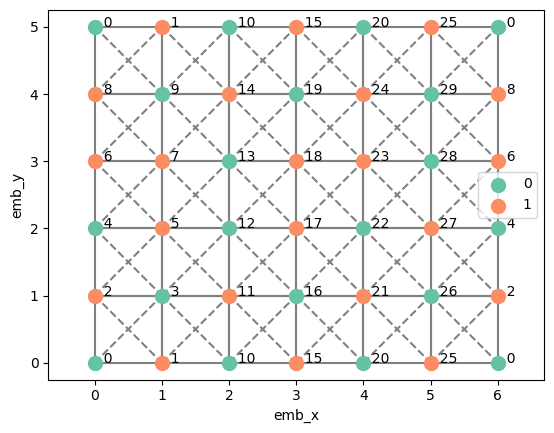

In [14]:
fourier.signal.lattice.plot(spins=195480038)